# Projet Bloc 5

**Projet Doument AI d'extraction d'informations dans des devis photovoltaïques**

## Objectifs du notebook

Le notebook couvre  les parties suivantes:

1. chargement du dataset et de ses labels ;
2. split par document en train, validation et test ;
3. fine-tuning de LayoutLMv3 ;
4. fine-tuning de LiLT ;
5. analyse des courbes d'apprentissage ;
6. évaluation finale sur le test isolé ;
7. comparaison et sélection du modèle de référence.



## Imports des librairies


In [35]:
import csv
import json
import random
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any
from IPython.display import display
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import Dataset, load_from_disk


from seqeval.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import (
    AutoProcessor,
    AutoTokenizer,
    LayoutLMv3ForTokenClassification,
    LayoutLMv3Processor,
    LiltForTokenClassification,
    Trainer,
    TrainingArguments,
)


## Paramètres et prérequis

Le notebook doit être exécuté depuis la racine du projet `document-intelligence-engine`.

Le dataset créé lors de l'étape précédente doit être disponible dans les répertoires suivantes:

```text
dataset/processed/layoutlm_full/dataset
dataset/processed/layoutlm_full/labels.json
```



In [49]:
RUN_LAYOUTLMV3_TRAINING = False
RUN_LILT_TRAINING = True
RUN_FINAL_TEST_EVALUATION = True

LAYOUTLMV3_LEARNING_RATE = 5e-5
NUM_EPOCHS = 10


## Fonctions utilitaires de visualisation

In [37]:
def charger_historique_entrainement(csv_path: str | Path) -> pd.DataFrame:
    # Charge et contrôle un historique d'entraînement sauvegardé en CSV.
    path = Path(csv_path)
    if not path.exists():
        raise FileNotFoundError(f"Fichier de métriques introuvable : {path}")

    history = pd.read_csv(path)
    required_columns = {"epoch", "train_loss", "eval_loss", "f1"}
    missing = required_columns.difference(history.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans {path.name} : {sorted(missing)}")
    return history.sort_values("epoch").reset_index(drop=True)


def visualiser_entrainement(history: pd.DataFrame, model_name: str) -> None:
    # Affiche le F1-score et les losses d'entraînement/validation.
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].plot(history["epoch"], history["f1"], marker="o", linewidth=2)
    best_index = history["f1"].idxmax()
    best_epoch = history.loc[best_index, "epoch"]
    best_f1 = history.loc[best_index, "f1"]
    axes[0].scatter(best_epoch, best_f1, s=90, zorder=3, label=f"Meilleur F1 : {best_f1:.3f}")
    axes[0].set(title=f"{model_name} — F1 validation", xlabel="Époque", ylabel="F1")
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_loss"], marker="o", label="Train")
    axes[1].plot(history["epoch"], history["eval_loss"], marker="o", label="Validation")
    axes[1].set(title=f"{model_name} — évolution de la loss", xlabel="Époque", ylabel="Loss")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def afficher_meilleure_epoque(history: pd.DataFrame, model_name: str) -> pd.DataFrame:
    # Retourne la ligne correspondant au meilleur F1 de validation.
    best_row = history.loc[[history["f1"].idxmax()]].copy()
    best_row.insert(0, "model", model_name)
    display(best_row)
    return best_row


## Fine-tuning de LayoutLMv3

LayoutLMv3 exploite trois modalités : le texte, la position des tokens et l'image de la page. Le checkpoint pré-entraîné est spécialisé sur onze classes BIO : cinq entités avec labels `B`/`I`, plus la classe `O`.

### Paramètres de configuration de LayoutLMv3

In [38]:
MODEL_NAME = "microsoft/layoutlmv3-base"
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)
DATASET_DIR = (PROJECT_ROOT / "dataset"/ "processed"/ "layoutlm_full"/ "dataset")
LABELS_DIR = (PROJECT_ROOT / "dataset"/ "processed"/ "layoutlm_full"/ "labels.json")
LABELS_PATH = Path(LABELS_DIR)
OUTPUT_DIR = Path(
    "models/layoutlmv3-photovoltaic-full-split-70-15-15"
)
FINAL_MODEL_DIR = OUTPUT_DIR / "final"
METRICS_CSV_PATH = OUTPUT_DIR / "training_metrics.csv"
MAX_LENGTH = 512
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42
EPOCH = NUM_EPOCHS

### Fonctions de chargement des labels, encodage multimodal et split par document

Le split se fait au niveau **document**, et non au niveau page, afin d'éviter qu'un même devis apparaisse dans plusieurs ensembles.

In [39]:
# Fonction qui charge depuis un fichier JSON les correspondances entre les 
# nom et les identifiants numériques utilisés par le modèle
def load_labels() -> tuple[dict[str, int], dict[int, str]]:
    with LABELS_DIR.open("r", encoding="utf-8") as file:
        payload = json.load(file)

    label2id = {
        label: int(label_id)
        for label, label_id in payload["label2id"].items()
    }
    id2label = {
        int(label_id): label
        for label_id, label in payload["id2label"].items()
    }
    return label2id, id2label


# Fonction qui transorme les données bruts du dataset en données numériques utilisable
# par le modèle. La tranformation se fait par le processor du modèle LayoutLmv3. 
# Ce processor traite les 3 types de données (texte, position et image)
# Convertit chaque page annotée eb ebtrée multimodale pour LayoutLMV3.
# Elle renvoie un dictionnaire
def encode_example(
    example: dict[str, Any],
    processor: LayoutLMv3Processor,
) -> dict[str, Any]:

    image_path = Path(example["image_path"])

    # Les chemins du dataset sont relatifs à la racine du projet.
    if not image_path.is_absolute():
        image_path = PROJECT_ROOT / image_path

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image introuvable : {image_path.resolve()}"
        )

    with Image.open(image_path) as source_image:
        # LayoutLMv3 attend une image RGB composée de trois canaux.
        image = source_image.convert("RGB")

    encoding = processor(
        image,
        example["tokens"],
        boxes=example["bboxes"],
        word_labels=example["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

    return {
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"],
        "bbox": encoding["bbox"],
        "labels": encoding["labels"],
        "pixel_values": encoding["pixel_values"][0],
    }

# Parcours le dataset avec la méthode map de hugging fae et applique encode_exemple
# à chaque page 
def encode_dataset(dataset: Dataset, processor: LayoutLMv3Processor) -> Dataset:
    return dataset.map(
        lambda example: encode_example(example, processor),
        remove_columns=dataset.column_names,
        desc="Encodage",
    )

# fonction qui sert à découper le dataset en 3 sous ensembles
# de donnée de train/test/validation
def split_by_document(
    dataset: Dataset,
    train_ratio: float = TRAIN_RATIO,
    validation_ratio: float = VALIDATION_RATIO,
    test_ratio: float = TEST_RATIO,
    seed: int = SEED,
) -> tuple[Dataset, Dataset, Dataset]:
    ratio_sum = train_ratio + validation_ratio + test_ratio

    if abs(ratio_sum - 1.0) > 1e-9:
        raise ValueError(
            "La somme des ratios train, validation et test "
            f"doit être égale à 1.0, reçu : {ratio_sum}"
        )

    if min(train_ratio, validation_ratio, test_ratio) <= 0:
        raise ValueError(
            "Les ratios doivent être strictement positifs."
        )

    documents: dict[str, list[int]] = defaultdict(list)

    for index, example in enumerate(dataset):
        document_id = example["id"].rsplit("_page_", 1)[0]
        documents[document_id].append(index)

    document_ids = sorted(documents.keys())

    if len(document_ids) < 3:
        raise ValueError(
            "Le dataset doit contenir au moins trois documents."
        )

    random.Random(seed).shuffle(document_ids)

    document_count = len(document_ids)
    train_end = int(document_count * train_ratio)
    validation_end = train_end + int(
        document_count * validation_ratio
    )

    train_docs = set(document_ids[:train_end])
    validation_docs = set(
        document_ids[train_end:validation_end]
    )
    test_docs = set(document_ids[validation_end:])

    if not train_docs or not validation_docs or not test_docs:
        raise ValueError(
            "Au moins un des splits train, validation ou test est vide."
        )

    train_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in train_docs
        for index in indices
    ]
    validation_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in validation_docs
        for index in indices
    ]
    test_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in test_docs
        for index in indices
    ]

    train_dataset = dataset.select(train_indices)
    validation_dataset = dataset.select(validation_indices)
    test_dataset = dataset.select(test_indices)

    if not train_docs.isdisjoint(validation_docs):
        raise ValueError("Fuite de documents entre train et validation.")
    if not train_docs.isdisjoint(test_docs):
        raise ValueError("Fuite de documents entre train et test.")
    if not validation_docs.isdisjoint(test_docs):
        raise ValueError("Fuite de documents entre validation et test.")

    if len(train_docs | validation_docs | test_docs) != document_count:
        raise ValueError("Tous les documents n'ont pas été répartis.")

    if (
        len(train_dataset)
        + len(validation_dataset)
        + len(test_dataset)
        != len(dataset)
    ):
        raise ValueError("Toutes les pages n'ont pas été réparties.")

    print("\n===== Split par devis =====")
    print(f"Documents train      : {len(train_docs)}")
    print(f"Documents validation : {len(validation_docs)}")
    print(f"Documents test       : {len(test_docs)}")
    print(f"Pages train          : {len(train_dataset)}")
    print(f"Pages validation     : {len(validation_dataset)}")
    print(f"Pages test           : {len(test_dataset)}")

    return train_dataset, validation_dataset, test_dataset


### Fonctions dédiées à la surcharge du Trainer de HuggingFace et autres fonctions d'affichage

La classe `O` est très majoritaire. Des poids de classes sont donc calculés pour augmenter l'importance des entités rares dans la fonction de perte. Le F1-score est utilisé comme métrique principale.

In [40]:
def print_raw_label_distribution(dataset: Dataset, id2label: dict[int, str]) -> None:
    counts: Counter[int] = Counter()
    for example in dataset:
        counts.update(example["ner_tags"])

    print("\n===== Distribution des labels dans le dataset brut =====")
    for label_id, label in id2label.items():
        print(f"{label:<25} : {counts.get(label_id, 0)}")

def print_encoded_label_distribution(
    dataset: Dataset,
    id2label: dict[int, str],
    dataset_name: str,
) -> None:
    counts: Counter[int] = Counter()

    for example in dataset:
        counts.update(
            int(label_id)
            for label_id in example["labels"]
            if label_id != -100
        )

    print(f"\n===== Distribution des labels après encodage : {dataset_name} =====")
    for label_id, label in id2label.items():
        print(f"{label:<25} : {counts.get(label_id, 0)}")

# Calcule le poids pour chaque classe en fonction de sa fréquence.
# PErmet de réduire l'impact du déséquilibre des classes, surtout du label 0
# On ignore le token special -100
# Objectif est de minimiser les tokens hors labels.
# Utilisé par la fonction de perte afin de limiter le biais du modèle 
# Utilisé uniqment pour le train dataset
def compute_class_weights(dataset: Dataset, num_labels: int) -> torch.Tensor:
    counts: Counter[int] = Counter()

    for example in dataset:
        counts.update(
            int(label_id)
            for label_id in example["labels"]
            if label_id != -100
        )

    total = sum(counts.values())
    weights = [
        total / (num_labels * max(counts.get(label_id, 0), 1))
        for label_id in range(num_labels)
    ]
    return torch.tensor(weights, dtype=torch.float)

# contruit la la fonction d'évaluation utilisée par le Trainer de HugginFace.
# Calcul la précision, le rappel, le F1 score et l'accuracy
def build_compute_metrics(id2label: dict[int, str]):
    def compute_metrics(eval_prediction):
        logits, labels = eval_prediction
        predicted_ids = np.argmax(logits, axis=-1)

        true_predictions: list[list[str]] = []
        true_labels: list[list[str]] = []

        for prediction_sequence, label_sequence in zip(predicted_ids, labels):
            current_predictions: list[str] = []
            current_labels: list[str] = []

            for predicted_id, label_id in zip(prediction_sequence, label_sequence):
                if label_id == -100:
                    continue

                current_predictions.append(id2label[int(predicted_id)])
                current_labels.append(id2label[int(label_id)])

            true_predictions.append(current_predictions)
            true_labels.append(current_labels)

        predicted_distribution = Counter(
            label
            for sequence in true_predictions
            for label in sequence
        )
        real_distribution = Counter(
            label
            for sequence in true_labels
            for label in sequence
        )

        print("\n===== Distribution des labels réels en validation =====")
        for label in id2label.values():
            print(f"{label:<25} : {real_distribution.get(label, 0)}")

        print("\n===== Distribution des labels prédits en validation =====")
        for label in id2label.values():
            print(f"{label:<25} : {predicted_distribution.get(label, 0)}")

        return {
            "precision": precision_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "accuracy": accuracy_score(true_labels, true_predictions),
        }

    return compute_metrics

# Classe qui herite du Trainer de HugginFace et remplace la fonction de loss
# On utilise cette nouvelle fonction de loss pour réduire l'influence de 
# la classe majoritaire 0
# Le Trainer par défaut ne prend pas en compte les datset déséquilibrés.
# Le trainer classique prend en charge les fonctionalités suivantes:
#   - constuire les bpatch
#   - Appeler le modèle
#   - calcul des gradients, 
#   - Mettre à jour des paramètres
#   - Evaluer le modèle
#   - Caluler les métriques
#   - Sauvegarder  checkpoints
#   - Appliquer le early stopping si configué
#   - Gérer le CPU, GPU...
class WeightedTrainer(Trainer):
    def __init__(self, class_weights: torch.Tensor, **kwargs) -> None:
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs: bool = False,
        **kwargs,
    ):
        model_inputs = inputs.copy()
        labels = model_inputs.pop("labels")
        outputs = model(**model_inputs)
        logits = outputs.logits

        loss_function = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            ignore_index=-100,
        )
        loss = loss_function(
            logits.reshape(-1, model.config.num_labels),
            labels.reshape(-1),
        )

        return (loss, outputs) if return_outputs else loss


### Fonctions de métriques d'évaluation

In [ ]:
def build_epoch_metrics(log_history: list[dict[str, Any]]) -> list[dict[str, float]]:
    """Construit une ligne par évaluation/époque depuis Trainer.state.log_history."""
    rows: list[dict[str, float]] = []
    latest_train_loss: float | None = None
    latest_learning_rate: float | None = None

    for entry in log_history:
        if "loss" in entry:
            latest_train_loss = float(entry["loss"])
        if "learning_rate" in entry:
            latest_learning_rate = float(entry["learning_rate"])

        if "eval_loss" not in entry:
            continue

        rows.append(
            {
                "epoch": float(entry.get("epoch", len(rows) + 1)),
                "train_loss": latest_train_loss if latest_train_loss is not None else float("nan"),
                "eval_loss": float(entry["eval_loss"]),
                "precision": float(entry.get("eval_precision", 0.0)),
                "recall": float(entry.get("eval_recall", 0.0)),
                "f1": float(entry.get("eval_f1", 0.0)),
                "accuracy": float(entry.get("eval_accuracy", 0.0)),
                "learning_rate": (
                    latest_learning_rate
                    if latest_learning_rate is not None
                    else float("nan")
                ),
            }
        )

    return rows

def print_metrics_table(rows: list[dict[str, float]]) -> None:
    if not rows:
        print("\nAucune métrique d'évaluation trouvée.")
        return

    headers = [
        "Epoch",
        "Train loss",
        "Eval loss",
        "Precision",
        "Recall",
        "F1",
        "Accuracy",
        "Learning rate",
    ]
    widths = [7, 12, 11, 11, 9, 9, 10, 14]

    def format_row(values: list[str]) -> str:
        return " | ".join(
            value.rjust(width)
            for value, width in zip(values, widths)
        )

    print("\n===== Tableau récapitulatif des métriques =====")
    print(format_row(headers))
    print("-+-".join("-" * width for width in widths))

    for row in rows:
        print(
            format_row(
                [
                    f"{row['epoch']:.0f}",
                    f"{row['train_loss']:.4f}",
                    f"{row['eval_loss']:.4f}",
                    f"{row['precision']:.4f}",
                    f"{row['recall']:.4f}",
                    f"{row['f1']:.4f}",
                    f"{row['accuracy']:.4f}",
                    f"{row['learning_rate']:.2e}",
                ]
            )
        )

def save_metrics_csv(rows: list[dict[str, float]], path: Path) -> None:
    if not rows:
        return

    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    print(f"Métriques sauvegardées dans : {path}")



### Chargement du modèle LayoutLmv3 et du preprocessor associée

In [42]:
PROJECT_ROOT = Path.cwd().parent

learning_rate = LAYOUTLMV3_LEARNING_RATE

dataset = load_from_disk(str(DATASET_DIR))
label2id, id2label = load_labels()

print_raw_label_distribution(dataset, id2label)

processor = LayoutLMv3Processor.from_pretrained(
    MODEL_NAME,
    apply_ocr=False,
)
print("\nProcessor chargé avec succès")

model = LayoutLMv3ForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    label2id=label2id,
    id2label=id2label,
)




===== Distribution des labels dans le dataset brut =====
O                         : 51025
B-CLIENT                  : 142
I-CLIENT                  : 83
B-DATE_DEVIS              : 142
I-DATE_DEVIS              : 79
B-EMETTEUR_DEVIS          : 123
I-EMETTEUR_DEVIS          : 126
B-MONTANT_TOTAL           : 128
I-MONTANT_TOTAL           : 164
B-NUMERO_DEVIS            : 137
I-NUMERO_DEVIS            : 24

Processor chargé avec succès


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 19485.31it/s]
[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.dense.weight    | MISSING | 
classifier.out_proj.bias   | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.bias      | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Séparation du dataset en sous datasets de train/test/validation (70%/15%/15%)

In [43]:
# Split du dataset (train/validation/test) par document et non par page
train_raw, validation_raw, test_raw = split_by_document(dataset)

print("\n===== Dataset brut =====")
print("Train      :", len(train_raw))
print("Validation :", len(validation_raw))
print("Test       :", len(test_raw))




===== Split par devis =====
Documents train      : 105
Documents validation : 22
Documents test       : 23
Pages train          : 148
Pages validation     : 31
Pages test           : 35

===== Dataset brut =====
Train      : 148
Validation : 31
Test       : 35


### Encodage des datasets

In [45]:
# 3- Encodage des données dans le format attendu par le modèle à l'aide de son processor
train_dataset = encode_dataset(
    train_raw,
    processor,
)

validation_dataset = encode_dataset(
    validation_raw,
    processor,
)

test_dataset = encode_dataset(
    test_raw,
    processor,
)

print_encoded_label_distribution(train_dataset, id2label, "train")
print_encoded_label_distribution(validation_dataset, id2label, "validation")
print_encoded_label_distribution(test_dataset, id2label, "test")

#


===== Distribution des labels après encodage : train =====
O                         : 27925
B-CLIENT                  : 98
I-CLIENT                  : 58
B-DATE_DEVIS              : 97
I-DATE_DEVIS              : 48
B-EMETTEUR_DEVIS          : 85
I-EMETTEUR_DEVIS          : 89
B-MONTANT_TOTAL           : 68
I-MONTANT_TOTAL           : 85
B-NUMERO_DEVIS            : 95
I-NUMERO_DEVIS            : 14

===== Distribution des labels après encodage : validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

===== Distribution des labels après encodage : test =====
O                         : 6928
B-CLIENT                  : 21
I-CLIENT                  : 14
B-DATE_DEVIS              : 21
I-DAT

### Gestion du dataset desequilibré 

In [46]:
# 4 - Gestion du  dataset desequilibré
class_weights = compute_class_weights(train_dataset, len(label2id))

run_name = f"lr-{learning_rate:.0e}"

output_dir = Path(
    "models/layoutlmv3-hyperparameter"
) / run_name

final_model_dir = output_dir / "final"

metrics_csv_path = output_dir / "training_metrics.csv"
output_dir=str(output_dir)

print("\n===== Poids des classes =====")
for label_id, weight in enumerate(class_weights):
    print(f"{id2label[label_id]:<25} : {weight.item():.4f}")




===== Poids des classes =====
O                         : 0.0933
B-CLIENT                  : 26.5881
I-CLIENT                  : 44.9248
B-DATE_DEVIS              : 26.8622
I-DATE_DEVIS              : 54.2841
B-EMETTEUR_DEVIS          : 30.6545
I-EMETTEUR_DEVIS          : 29.2768
B-MONTANT_TOTAL           : 38.3182
I-MONTANT_TOTAL           : 30.6545
B-NUMERO_DEVIS            : 27.4278
I-NUMERO_DEVIS            : 186.1169


### Configuration de l'entrainement du modèle

In [47]:

training_args = TrainingArguments(
    output_dir=str(output_dir),
    learning_rate=learning_rate,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=EPOCH,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=5,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    save_total_limit=2,
    seed=SEED,
    data_seed=SEED,
    report_to="none",
)

print("\n===== Configuration entraînement =====")
print("Dossier de sortie :", training_args.output_dir)
print("Learning rate     :", training_args.learning_rate)
print("Batch train       :", training_args.per_device_train_batch_size)
print("Nombre d'epochs   :", training_args.num_train_epochs)
print("Évaluation        :", training_args.eval_strategy)


trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=build_compute_metrics(id2label),
)




===== Configuration entraînement =====
Dossier de sortie : models/layoutlmv3-hyperparameter/lr-5e-05
Learning rate     : 5e-05
Batch train       : 2
Nombre d'epochs   : 10
Évaluation        : IntervalStrategy.EPOCH


### Entrainement du modèle, sauvegarde des métriques et du meilleur checkpoint

In [50]:
if RUN_LAYOUTLMV3_TRAINING:
    print("\n===== Début du fine-tuning =====")
    train_result = trainer.train()

    metrics_rows = build_epoch_metrics(trainer.state.log_history)
    print_metrics_table(metrics_rows)
    save_metrics_csv(metrics_rows, metrics_csv_path)



### Evaluation du modèle

In [51]:
# 7- Evaluation du modèlegit status
final_metrics = trainer.evaluate()
print("\n===== Métriques finales du meilleur checkpoint =====")
for metric_name in (
    "eval_loss",
    "eval_precision",
    "eval_recall",
    "eval_f1",
    "eval_accuracy",
):
    if metric_name in final_metrics:
        print(f"{metric_name:<20} : {final_metrics[metric_name]:.4f}")


# Le jeu de test reste isolé pendant la sélection du modèle
# et des hyperparamètres. Il sera évalué une seule fois
# après le choix définitif de la configuration.

final_model_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(final_model_dir))
processor.save_pretrained(str(final_model_dir))

print("\n===== Fine-tuning terminé =====")
print(train_result)
print(f"Modèle sauvegardé dans : {final_model_dir}")


/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



===== Distribution des labels réels en validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

===== Distribution des labels prédits en validation =====
O                         : 5227
B-CLIENT                  : 22
I-CLIENT                  : 11
B-DATE_DEVIS              : 33
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 20
I-EMETTEUR_DEVIS          : 25
B-MONTANT_TOTAL           : 14
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 26
I-NUMERO_DEVIS            : 0


Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.105748,0.895280,10,0.696721,0.858586,0.769231,0.987267



===== Métriques finales du meilleur checkpoint =====
eval_loss            : 0.8953
eval_precision       : 0.6967
eval_recall          : 0.8586
eval_f1              : 0.7692
eval_accuracy        : 0.9873


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.28it/s]


===== Fine-tuning terminé =====
TrainOutput(global_step=740, training_loss=0.21750513538214805, metrics={'train_runtime': 1357.3958, 'train_samples_per_second': 1.09, 'train_steps_per_second': 0.545, 'total_flos': 392835055165440.0, 'train_loss': 0.21750513538214805, 'epoch': 10.0})
Modèle sauvegardé dans : models/layoutlmv3-hyperparameter/lr-5e-05/final


### Visualisation des résultats LayoutLMv3

Cette cellule permet de présenter l'évolution du F1-score et des losses sans relancer l'entraînement si le CSV existe déjà.

,epoch,train_loss,eval_loss,precision,recall,f1,accuracy,learning_rate
0,1.0,0.907788,0.523528,0.111987,0.717172,0.193724,0.853479,4.533784e-05
1,2.0,0.277023,0.530135,0.319392,0.848485,0.464088,0.948514,4.027027e-05
2,3.0,0.164498,0.423324,0.303571,0.858586,0.448549,0.952943,3.520270e-05
3,4.0,0.039130,0.564193,0.447368,0.858586,0.588235,0.970290,3.013514e-05
4,5.0,0.250698,0.543813,0.338645,0.858586,0.485714,0.959771,2.506757e-05
5,6.0,0.019905,0.568352,0.508571,0.898990,0.649635,0.978963,2.033784e-05
6,7.0,0.013887,0.670102,0.535032,0.848485,0.656250,0.980808,1.527027e-05
7,8.0,0.011422,0.723505,0.524691,0.858586,0.651341,0.978225,1.020270e-05
8,9.0,0.011804,0.671256,0.600000,0.878788,0.713115,0.983392,5.135135e-06
9,10.0,0.105748,0.895280,0.696721,0.858586,0.769231,0.987267,6.756757e-08


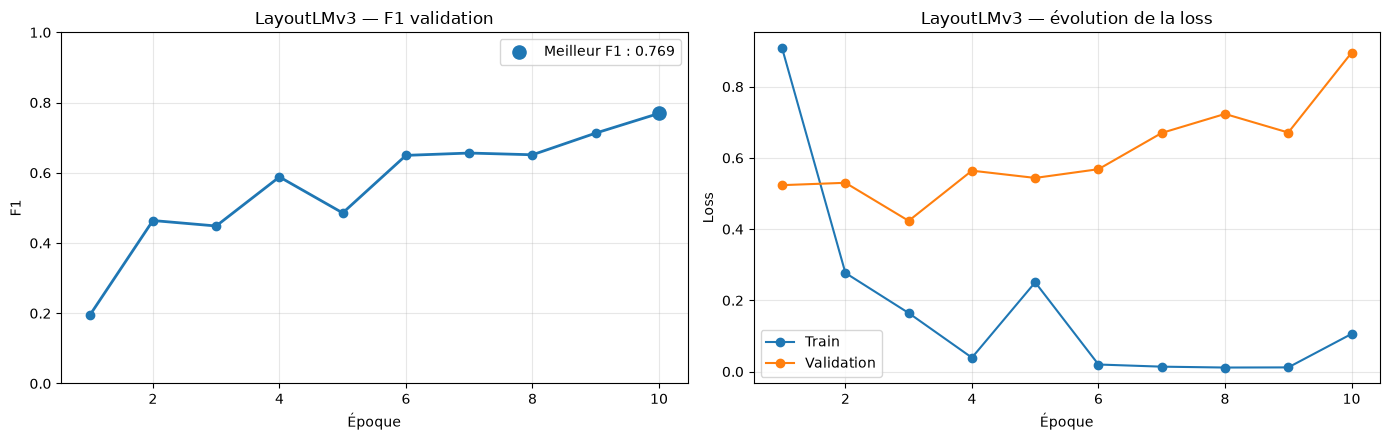

,model,epoch,train_loss,eval_loss,precision,recall,f1,accuracy,learning_rate
9,LayoutLMv3,10.0,0.105748,0.89528,0.696721,0.858586,0.769231,0.987267,6.756757e-08


In [52]:
layout_metrics_path = Path(
    "models/layoutlmv3-hyperparameter/lr-5e-05/training_metrics.csv"
)

if layout_metrics_path.exists():
    layout_history = charger_historique_entrainement(layout_metrics_path)
    display(layout_history)
    visualiser_entrainement(layout_history, "LayoutLMv3")
    layout_best_epoch = afficher_meilleure_epoque(layout_history, "LayoutLMv3")
else:
    print("CSV LayoutLMv3 introuvable :", layout_metrics_path)

### Interprétation des courbes

- La **train loss** mesure l'erreur sur les exemples utilisés pour apprendre.
- L'**eval loss** mesure l'erreur sur les exemples de validation non utilisés pour mettre à jour les poids.
- Le **F1-score** combine précision et rappel sur les entités.
- Si la train loss continue de baisser alors que l'eval loss remonte, le modèle commence à **surapprendre**.

Le checkpoint final n'est donc pas forcément celui de la dixième époque : `load_best_model_at_end=True` restaure celui qui a obtenu le meilleur F1 de validation.

## Fine-tuning de LiLT

LiLT exploite le texte et les positions, sans fournir l'image de la page au modèle. Le protocole reste identique afin que la comparaison avec LayoutLMv3 soit équitable.

### Configuration des paramètres LiLT

In [ ]:
MODEL_NAME = "SCUT-DLVCLab/lilt-roberta-en-base"
DATASET_DIR = Path("dataset/processed/layoutlm_full/dataset")
LABELS_PATH = Path("dataset/processed/layoutlm_full/labels.json")
OUTPUT_DIR = Path(
    "models/lilt-photovoltaic-full-split-70-15-15"
)
FINAL_MODEL_DIR = OUTPUT_DIR / "final"
METRICS_CSV_PATH = OUTPUT_DIR / "training_metrics.csv"
FINAL_METRICS_PATH = OUTPUT_DIR / "final_metrics.json"
MAX_LENGTH = 512
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42
EPOCH = NUM_EPOCHS


### 5.2 Encodage, pondération des classes et métriques LiLT

In [ ]:
def load_labels() -> tuple[dict[str, int], dict[int, str]]:
    with LABELS_PATH.open("r", encoding="utf-8") as file:
        payload = json.load(file)

    label2id = {
        label: int(label_id)
        for label, label_id in payload["label2id"].items()
    }
    id2label = {
        int(label_id): label
        for label_id, label in payload["id2label"].items()
    }
    return label2id, id2label

def encode_example(
    example: dict[str, Any],
    tokenizer,
) -> dict[str, Any]:
    encoding = tokenizer(
        example["tokens"],
        boxes=example["bboxes"],
        word_labels=example["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

    return {
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"],
        "bbox": encoding["bbox"],
        "labels": encoding["labels"],
    }

def encode_dataset(
    dataset: Dataset,
    tokenizer,
) -> Dataset:
    return dataset.map(
        lambda example: encode_example(example, tokenizer),
        remove_columns=dataset.column_names,
        desc="Encodage LiLT",
    )

def split_by_document(
    dataset: Dataset,
    train_ratio: float = TRAIN_RATIO,
    validation_ratio: float = VALIDATION_RATIO,
    test_ratio: float = TEST_RATIO,
    seed: int = SEED,
) -> tuple[Dataset, Dataset, Dataset]:
    ratio_sum = train_ratio + validation_ratio + test_ratio

    if abs(ratio_sum - 1.0) > 1e-9:
        raise ValueError(
            "La somme des ratios train, validation et test "
            f"doit être égale à 1.0, reçu : {ratio_sum}"
        )

    if min(train_ratio, validation_ratio, test_ratio) <= 0:
        raise ValueError(
            "Les ratios doivent être strictement positifs."
        )

    documents: dict[str, list[int]] = defaultdict(list)

    for index, example in enumerate(dataset):
        document_id = example["id"].rsplit("_page_", 1)[0]
        documents[document_id].append(index)

    document_ids = sorted(documents.keys())

    if len(document_ids) < 3:
        raise ValueError(
            "Le dataset doit contenir au moins trois documents."
        )

    random.Random(seed).shuffle(document_ids)

    document_count = len(document_ids)
    train_end = int(document_count * train_ratio)
    validation_end = train_end + int(
        document_count * validation_ratio
    )

    train_docs = set(document_ids[:train_end])
    validation_docs = set(
        document_ids[train_end:validation_end]
    )
    test_docs = set(document_ids[validation_end:])

    if not train_docs or not validation_docs or not test_docs:
        raise ValueError(
            "Au moins un des splits train, validation ou test est vide."
        )

    train_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in train_docs
        for index in indices
    ]
    validation_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in validation_docs
        for index in indices
    ]
    test_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in test_docs
        for index in indices
    ]

    train_dataset = dataset.select(train_indices)
    validation_dataset = dataset.select(validation_indices)
    test_dataset = dataset.select(test_indices)

    if not train_docs.isdisjoint(validation_docs):
        raise ValueError("Fuite de documents entre train et validation.")
    if not train_docs.isdisjoint(test_docs):
        raise ValueError("Fuite de documents entre train et test.")
    if not validation_docs.isdisjoint(test_docs):
        raise ValueError("Fuite de documents entre validation et test.")

    if len(train_docs | validation_docs | test_docs) != document_count:
        raise ValueError("Tous les documents n'ont pas été répartis.")

    if (
        len(train_dataset)
        + len(validation_dataset)
        + len(test_dataset)
        != len(dataset)
    ):
        raise ValueError("Toutes les pages n'ont pas été réparties.")

    print("\n===== Split par devis =====")
    print(f"Documents train      : {len(train_docs)}")
    print(f"Documents validation : {len(validation_docs)}")
    print(f"Documents test       : {len(test_docs)}")
    print(f"Pages train          : {len(train_dataset)}")
    print(f"Pages validation     : {len(validation_dataset)}")
    print(f"Pages test           : {len(test_dataset)}")

    return train_dataset, validation_dataset, test_dataset

def print_encoded_label_distribution(
    dataset: Dataset,
    id2label: dict[int, str],
    dataset_name: str,
) -> None:
    label_counts: Counter[int] = Counter()

    for example in dataset:
        label_counts.update(
            int(label_id)
            for label_id in example["labels"]
            if label_id != -100
        )

    print(
        "\n===== Distribution des labels après encodage : "
        f"{dataset_name} ====="
    )
    for label_id, label in id2label.items():
        print(f"{label:<25} : {label_counts.get(label_id, 0)}")

def compute_class_weights(
    dataset: Dataset,
    num_labels: int,
) -> torch.Tensor:
    label_counts: Counter[int] = Counter()

    for example in dataset:
        label_counts.update(
            int(label_id)
            for label_id in example["labels"]
            if label_id != -100
        )

    total_labels = sum(label_counts.values())
    weights = [
        total_labels
        / (num_labels * max(label_counts.get(label_id, 0), 1))
        for label_id in range(num_labels)
    ]

    return torch.tensor(weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def __init__(
        self,
        class_weights: torch.Tensor,
        **kwargs,
    ) -> None:
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs: bool = False,
        **kwargs,
    ):
        model_inputs = inputs.copy()
        labels = model_inputs.pop("labels")
        outputs = model(**model_inputs)
        logits = outputs.logits

        loss_function = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            ignore_index=-100,
        )
        loss = loss_function(
            logits.reshape(-1, model.config.num_labels),
            labels.reshape(-1),
        )

        return (loss, outputs) if return_outputs else loss

def build_compute_metrics(id2label: dict[int, str]):
    def compute_metrics(eval_prediction):
        logits, labels = eval_prediction
        predicted_ids = np.argmax(logits, axis=-1)

        true_predictions: list[list[str]] = []
        true_labels: list[list[str]] = []

        for prediction_sequence, label_sequence in zip(
            predicted_ids,
            labels,
        ):
            current_predictions: list[str] = []
            current_labels: list[str] = []

            for predicted_id, label_id in zip(
                prediction_sequence,
                label_sequence,
            ):
                if label_id == -100:
                    continue

                current_predictions.append(
                    id2label[int(predicted_id)]
                )
                current_labels.append(
                    id2label[int(label_id)]
                )

            true_predictions.append(current_predictions)
            true_labels.append(current_labels)

        return {
            "precision": precision_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "accuracy": accuracy_score(
                true_labels,
                true_predictions,
            ),
        }

    return compute_metrics


### 5.3 Suivi des époques et smoke test

In [ ]:
def build_epoch_metrics(
    log_history: list[dict[str, Any]],
) -> list[dict[str, float | None]]:
    rows: list[dict[str, float | None]] = []
    latest_train_loss: float | None = None
    latest_learning_rate: float | None = None

    for entry in log_history:
        if "loss" in entry:
            latest_train_loss = float(entry["loss"])
        if "learning_rate" in entry:
            latest_learning_rate = float(entry["learning_rate"])

        if "eval_loss" not in entry:
            continue

        rows.append(
            {
                "epoch": float(entry["epoch"]),
                "train_loss": latest_train_loss,
                "eval_loss": float(entry["eval_loss"]),
                "precision": float(
                    entry.get("eval_precision", 0.0)
                ),
                "recall": float(
                    entry.get("eval_recall", 0.0)
                ),
                "f1": float(entry.get("eval_f1", 0.0)),
                "accuracy": float(
                    entry.get("eval_accuracy", 0.0)
                ),
                "learning_rate": latest_learning_rate,
            }
        )

    return rows

def print_metrics_table(
    rows: list[dict[str, float | None]],
) -> None:
    if not rows:
        print("\nAucune métrique par époque disponible.")
        return

    print("\n===== Métriques LiLT par époque =====")
    header = (
        f"{'Epoch':>7} | "
        f"{'Train loss':>12} | "
        f"{'Eval loss':>11} | "
        f"{'Precision':>10} | "
        f"{'Recall':>8} | "
        f"{'F1':>8} | "
        f"{'Accuracy':>10} | "
        f"{'Learning rate':>13}"
    )
    print(header)
    print("-" * len(header))

    for row in rows:
        train_loss = row["train_loss"]
        learning_rate = row["learning_rate"]
        print(
            f"{row['epoch']:>7.0f} | "
            f"{train_loss if train_loss is not None else 0:>12.4f} | "
            f"{row['eval_loss']:>11.4f} | "
            f"{row['precision']:>10.4f} | "
            f"{row['recall']:>8.4f} | "
            f"{row['f1']:>8.4f} | "
            f"{row['accuracy']:>10.4f} | "
            f"{learning_rate if learning_rate is not None else 0:>13.2e}"
        )

def save_metrics_csv(
    rows: list[dict[str, float | None]],
    output_path: Path,
) -> None:
    if not rows:
        return

    output_path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = [
        "epoch",
        "train_loss",
        "eval_loss",
        "precision",
        "recall",
        "f1",
        "accuracy",
        "learning_rate",
    ]

    with output_path.open(
        "w",
        newline="",
        encoding="utf-8",
    ) as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=fieldnames,
        )
        writer.writeheader()
        writer.writerows(rows)

    print("\nMétriques sauvegardées dans :", output_path)

def run_smoke_test(
    dataset: Dataset,
    tokenizer,
    model: LiltForTokenClassification,
) -> None:
    example = dataset[0]

    encoding = tokenizer(
        example["tokens"],
        boxes=example["bboxes"],
        word_labels=example["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    print("\n===== Smoke test LiLT =====")
    for key, value in encoding.items():
        print(f"{key:<15} : {value.shape}")

    model.eval()
    with torch.no_grad():
        outputs = model(**encoding)

    print(f"Loss initiale : {outputs.loss.item():.4f}")
    print("Logits        :", outputs.logits.shape)


### 5.4 Protocole expérimental contrôlé

LiLT est entraîné avec le même split, la même seed, le même nombre d'époques, le même learning rate, la même loss pondérée et la même métrique de sélection. Cette symétrie isole autant que possible l'effet de l'architecture dans la comparaison.

La différence essentielle reste l'entrée du modèle : LiLT utilise les tokens et leurs coordonnées 2D, tandis que LayoutLMv3 ajoute les caractéristiques visuelles de la page.

### 5.5 Exécution du fine-tuning LiLT

Le meilleur checkpoint est également sélectionné selon le F1-score de validation.

In [ ]:
if RUN_LILT_TRAINING:
    print("===== Chargement LiLT =====")

    label2id, id2label = load_labels()

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    model = LiltForTokenClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label2id),
        label2id=label2id,
        id2label=id2label,
    )

    dataset = load_from_disk(str(DATASET_DIR))

    run_smoke_test(dataset, tokenizer, model)

    train_raw, validation_raw, test_raw = split_by_document(
        dataset
    )

    print("\n===== Dataset brut =====")
    print("Train      :", len(train_raw))
    print("Validation :", len(validation_raw))
    print("Test       :", len(test_raw))

    train_dataset = encode_dataset(train_raw, tokenizer)
    validation_dataset = encode_dataset(
        validation_raw,
        tokenizer,
    )
    test_dataset = encode_dataset(test_raw, tokenizer)

    print_encoded_label_distribution(
        train_dataset,
        id2label,
        "train",
    )
    print_encoded_label_distribution(
        validation_dataset,
        id2label,
        "validation",
    )
    print_encoded_label_distribution(
        test_dataset,
        id2label,
        "test",
    )

    class_weights = compute_class_weights(
        train_dataset,
        num_labels=len(label2id),
    )

    print("\n===== Poids des classes =====")
    for label_id, weight in enumerate(class_weights):
        print(
            f"{id2label[label_id]:<25} : "
            f"{weight.item():.4f}"
        )

    training_args = TrainingArguments(
        output_dir=str(OUTPUT_DIR),
        learning_rate=5e-5,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        num_train_epochs=EPOCH,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=5,
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1",
        greater_is_better=True,
        report_to="none",
        save_total_limit=2,
        seed=SEED,
        data_seed=SEED,
    )

    trainer = WeightedTrainer(
        class_weights=class_weights,
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        compute_metrics=build_compute_metrics(id2label),
    )

    print("\n===== Début du fine-tuning LiLT =====")
    train_result = trainer.train()

    epoch_metrics = build_epoch_metrics(
        trainer.state.log_history
    )
    print_metrics_table(epoch_metrics)
    save_metrics_csv(epoch_metrics, METRICS_CSV_PATH)

    print("\n===== Évaluation finale sur la validation =====")
    final_metrics = trainer.evaluate()

    FINAL_METRICS_PATH.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    with FINAL_METRICS_PATH.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                key: float(value)
                if isinstance(value, (int, float))
                else value
                for key, value in final_metrics.items()
            },
            file,
            ensure_ascii=False,
            indent=2,
        )

    for metric_name, metric_value in final_metrics.items():
        if isinstance(metric_value, float):
            print(f"{metric_name:<30} : {metric_value:.4f}")
        else:
            print(f"{metric_name:<30} : {metric_value}")

    # Le jeu de test reste isolé pendant la sélection du modèle
    # et des hyperparamètres. Il sera évalué une seule fois
    # après le choix définitif de la configuration.

    FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(FINAL_MODEL_DIR))
    tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

    print("\n===== Fine-tuning LiLT terminé =====")
    print(train_result)
    print(f"Modèle sauvegardé dans : {FINAL_MODEL_DIR}")


### 5.6 Visualisation des résultats LiLT

In [ ]:
lilt_metrics_path = Path(
    "models/lilt-photovoltaic-full-split-70-15-15/training_metrics.csv"
)

if lilt_metrics_path.exists():
    lilt_history = charger_historique_entrainement(lilt_metrics_path)
    display(lilt_history)
    visualiser_entrainement(lilt_history, "LiLT")
    lilt_best_epoch = afficher_meilleure_epoque(lilt_history, "LiLT")
else:
    print("CSV LiLT introuvable :", lilt_metrics_path)

## 6. Évaluation finale sur le jeu de test

Cette partie intervient **après** le choix des configurations et des checkpoints. Elle ne modifie plus les poids : elle mesure uniquement la généralisation sur les 23 documents / 35 pages de test.

### 6.1 Évaluation finale de LayoutLMv3

In [ ]:
DATASET_DIR = Path(
    "dataset/processed/layoutlm_full/dataset"
)
LABELS_PATH = Path(
    "dataset/processed/layoutlm_full/labels.json"
)
MODEL_DIR = Path(
    "models/layoutlmv3-hyperparameter/lr-5e-05/final"
)
OUTPUT_DIR = Path(
    "models/layoutlmv3-hyperparameter/lr-5e-05/test-evaluation"
)
TEST_METRICS_PATH = OUTPUT_DIR / "test_metrics.json"
MAX_LENGTH = 512
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42


In [ ]:
def load_labels() -> tuple[dict[str, int], dict[int, str]]:
    with LABELS_PATH.open(
        "r",
        encoding="utf-8",
    ) as file:
        payload = json.load(file)

    label2id = {
        label: int(label_id)
        for label, label_id in payload["label2id"].items()
    }

    id2label = {
        int(label_id): label
        for label_id, label in payload["id2label"].items()
    }

    return label2id, id2label

def split_by_document(
    dataset: Dataset,
    train_ratio: float = TRAIN_RATIO,
    validation_ratio: float = VALIDATION_RATIO,
    test_ratio: float = TEST_RATIO,
    seed: int = SEED,
) -> tuple[Dataset, Dataset, Dataset]:
    ratio_sum = train_ratio + validation_ratio + test_ratio

    if abs(ratio_sum - 1.0) > 1e-9:
        raise ValueError(
            "La somme des ratios train, validation et test "
            f"doit être égale à 1.0, reçu : {ratio_sum}"
        )

    documents: dict[str, list[int]] = defaultdict(list)

    for index, example in enumerate(dataset):
        document_id = example["id"].rsplit(
            "_page_",
            1,
        )[0]

        documents[document_id].append(index)

    document_ids = sorted(documents.keys())
    random.Random(seed).shuffle(document_ids)

    document_count = len(document_ids)

    train_end = int(document_count * train_ratio)
    validation_end = train_end + int(
        document_count * validation_ratio
    )

    train_docs = set(document_ids[:train_end])
    validation_docs = set(
        document_ids[train_end:validation_end]
    )
    test_docs = set(document_ids[validation_end:])

    train_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in train_docs
        for index in indices
    ]

    validation_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in validation_docs
        for index in indices
    ]

    test_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in test_docs
        for index in indices
    ]

    train_dataset = dataset.select(train_indices)
    validation_dataset = dataset.select(validation_indices)
    test_dataset = dataset.select(test_indices)

    if not train_docs.isdisjoint(validation_docs):
        raise ValueError("Fuite entre train et validation.")

    if not train_docs.isdisjoint(test_docs):
        raise ValueError("Fuite entre train et test.")

    if not validation_docs.isdisjoint(test_docs):
        raise ValueError("Fuite entre validation et test.")

    print("\n===== Split final =====")
    print("Documents train      :", len(train_docs))
    print("Documents validation :", len(validation_docs))
    print("Documents test       :", len(test_docs))
    print("Pages test           :", len(test_dataset))

    return (
        train_dataset,
        validation_dataset,
        test_dataset,
    )

def encode_example(
    example: dict,
    processor,
) -> dict:
    image = Image.open(
        example["image_path"]
    ).convert("RGB")

    encoding = processor(
        images=image,
        text=example["tokens"],
        boxes=example["bboxes"],
        word_labels=example["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="np",
    )

    return {
        "input_ids": encoding["input_ids"][0],
        "attention_mask": encoding["attention_mask"][0],
        "bbox": encoding["bbox"][0],
        "pixel_values": encoding["pixel_values"][0],
        "labels": encoding["labels"][0],
    }

def encode_dataset(
    dataset: Dataset,
    processor,
) -> Dataset:
    return dataset.map(
        lambda example: encode_example(
            example,
            processor,
        ),
        remove_columns=dataset.column_names,
        desc="Encodage du jeu de test LayoutLMv3",
    )

def build_compute_metrics(
    id2label: dict[int, str],
):
    def compute_metrics(eval_prediction):
        logits, labels = eval_prediction

        predicted_ids = np.argmax(
            logits,
            axis=-1,
        )

        true_predictions: list[list[str]] = []
        true_labels: list[list[str]] = []

        for prediction_sequence, label_sequence in zip(
            predicted_ids,
            labels,
        ):
            current_predictions: list[str] = []
            current_labels: list[str] = []

            for predicted_id, label_id in zip(
                prediction_sequence,
                label_sequence,
            ):
                if label_id == -100:
                    continue

                current_predictions.append(
                    id2label[int(predicted_id)]
                )

                current_labels.append(
                    id2label[int(label_id)]
                )

            true_predictions.append(
                current_predictions
            )

            true_labels.append(
                current_labels
            )

        predicted_distribution = Counter(
            label
            for sequence in true_predictions
            for label in sequence
        )

        real_distribution = Counter(
            label
            for sequence in true_labels
            for label in sequence
        )

        print(
            "\n===== Distribution réelle sur le test ====="
        )

        for label in id2label.values():
            print(
                f"{label:<25} : "
                f"{real_distribution.get(label, 0)}"
            )

        print(
            "\n===== Distribution prédite sur le test ====="
        )

        for label in id2label.values():
            print(
                f"{label:<25} : "
                f"{predicted_distribution.get(label, 0)}"
            )

        return {
            "precision": precision_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "accuracy": accuracy_score(
                true_labels,
                true_predictions,
            ),
        }

    return compute_metrics


In [ ]:
if RUN_FINAL_TEST_EVALUATION:
    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    _, id2label = load_labels()

    dataset = load_from_disk(
        str(DATASET_DIR)
    )

    # 2 - Récupérer les dataset de test non utilisés pendant l'entrainement
    _, _, test_raw = split_by_document(
        dataset
    )

    # 3 - Charger 
    processor = AutoProcessor.from_pretrained(
        MODEL_DIR,
        apply_ocr=False,
    )

    model = (
        LayoutLMv3ForTokenClassification.from_pretrained(
            MODEL_DIR
        )
    )

    # Encoder le jeu de test
    test_dataset = encode_dataset(
        test_raw,
        processor,
    )

    evaluation_args = TrainingArguments(
        output_dir=str(OUTPUT_DIR),
        per_device_eval_batch_size=2,
        report_to="none",
        seed=SEED,
        data_seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=evaluation_args,
        compute_metrics=build_compute_metrics(
            id2label
        ),
    )

    print(
        "\n===== Évaluation finale LayoutLMv3 "
        "sur le test ====="
    )

    # Prédire sans changer les poids - juste de l'inférence
    test_metrics = trainer.evaluate(
        eval_dataset=test_dataset,
        metric_key_prefix="test",
    )

    print(
        "\n===== Métriques finales du test ====="
    )

    for metric_name, metric_value in test_metrics.items():
        if isinstance(metric_value, float):
            print(
                f"{metric_name:<30} : "
                f"{metric_value:.4f}"
            )
        else:
            print(
                f"{metric_name:<30} : "
                f"{metric_value}"
            )

    serializable_metrics = {
        key: float(value)
        if isinstance(value, (int, float))
        else value
        for key, value in test_metrics.items()
    }

    with TEST_METRICS_PATH.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            serializable_metrics,
            file,
            ensure_ascii=False,
            indent=2,
        )

    print(
        "\nMétriques sauvegardées dans :",
        TEST_METRICS_PATH,
    )


### 6.2 Évaluation finale de LiLT

In [ ]:
DATASET_DIR = Path(
    "dataset/processed/layoutlm_full/dataset"
)
LABELS_PATH = Path(
    "dataset/processed/layoutlm_full/labels.json"
)
MODEL_DIR = Path(
    "models/lilt-photovoltaic-full-split-70-15-15/final"
)
OUTPUT_DIR = Path(
    "models/lilt-photovoltaic-full-split-70-15-15/test-evaluation"
)
TEST_METRICS_PATH = OUTPUT_DIR / "test_metrics.json"
MAX_LENGTH = 512
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42


In [ ]:


def split_by_document(
    dataset: Dataset,
    train_ratio: float = TRAIN_RATIO,
    validation_ratio: float = VALIDATION_RATIO,
    test_ratio: float = TEST_RATIO,
    seed: int = SEED,
) -> tuple[Dataset, Dataset, Dataset]:
    ratio_sum = train_ratio + validation_ratio + test_ratio

    if abs(ratio_sum - 1.0) > 1e-9:
        raise ValueError(
            "La somme des ratios train, validation et test "
            f"doit être égale à 1.0, reçu : {ratio_sum}"
        )

    documents: dict[str, list[int]] = defaultdict(list)

    for index, example in enumerate(dataset):
        document_id = example["id"].rsplit(
            "_page_",
            1,
        )[0]

        documents[document_id].append(index)

    document_ids = sorted(documents.keys())

    random.Random(seed).shuffle(document_ids)

    document_count = len(document_ids)

    train_end = int(
        document_count * train_ratio
    )

    validation_end = train_end + int(
        document_count * validation_ratio
    )

    train_docs = set(
        document_ids[:train_end]
    )

    validation_docs = set(
        document_ids[train_end:validation_end]
    )

    test_docs = set(
        document_ids[validation_end:]
    )

    train_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in train_docs
        for index in indices
    ]

    validation_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in validation_docs
        for index in indices
    ]

    test_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in test_docs
        for index in indices
    ]

    train_dataset = dataset.select(
        train_indices
    )

    validation_dataset = dataset.select(
        validation_indices
    )

    test_dataset = dataset.select(
        test_indices
    )

    if not train_docs.isdisjoint(validation_docs):
        raise ValueError(
            "Fuite entre train et validation."
        )

    if not train_docs.isdisjoint(test_docs):
        raise ValueError(
            "Fuite entre train et test."
        )

    if not validation_docs.isdisjoint(test_docs):
        raise ValueError(
            "Fuite entre validation et test."
        )

    print("\n===== Split final =====")
    print("Documents train      :", len(train_docs))
    print("Documents validation :", len(validation_docs))
    print("Documents test       :", len(test_docs))
    print("Pages test           :", len(test_dataset))

    return (
        train_dataset,
        validation_dataset,
        test_dataset,
    )

def encode_example(
    example: dict,
    tokenizer,
) -> dict:
    encoding = tokenizer(
        example["tokens"],
        boxes=example["bboxes"],
        word_labels=example["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

    return {
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"],
        "bbox": encoding["bbox"],
        "labels": encoding["labels"],
    }

def encode_dataset(
    dataset: Dataset,
    tokenizer,
) -> Dataset:
    return dataset.map(
        lambda example: encode_example(
            example,
            tokenizer,
        ),
        remove_columns=dataset.column_names,
        desc="Encodage du jeu de test",
    )

def build_compute_metrics(
    id2label: dict[int, str],
):
    def compute_metrics(eval_prediction):
        logits, labels = eval_prediction

        predicted_ids = np.argmax(
            logits,
            axis=-1,
        )

        true_predictions: list[list[str]] = []
        true_labels: list[list[str]] = []

        for prediction_sequence, label_sequence in zip(
            predicted_ids,
            labels,
        ):
            current_predictions: list[str] = []
            current_labels: list[str] = []

            for predicted_id, label_id in zip(
                prediction_sequence,
                label_sequence,
            ):
                if label_id == -100:
                    continue

                current_predictions.append(
                    id2label[int(predicted_id)]
                )

                current_labels.append(
                    id2label[int(label_id)]
                )

            true_predictions.append(
                current_predictions
            )

            true_labels.append(
                current_labels
            )

        predicted_distribution = Counter(
            label
            for sequence in true_predictions
            for label in sequence
        )

        real_distribution = Counter(
            label
            for sequence in true_labels
            for label in sequence
        )

        print(
            "\n===== Distribution réelle sur le test ====="
        )

        for label in id2label.values():
            print(
                f"{label:<25} : "
                f"{real_distribution.get(label, 0)}"
            )

        print(
            "\n===== Distribution prédite sur le test ====="
        )

        for label in id2label.values():
            print(
                f"{label:<25} : "
                f"{predicted_distribution.get(label, 0)}"
            )

        return {
            "precision": precision_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "accuracy": accuracy_score(
                true_labels,
                true_predictions,
            ),
        }

    return compute_metrics


In [ ]:
if RUN_FINAL_TEST_EVALUATION:
    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    _, id2label = load_labels()

    dataset = load_from_disk(
        str(DATASET_DIR)
    )

    _, _, test_raw = split_by_document(
        dataset
    )

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_DIR
    )

    model = LiltForTokenClassification.from_pretrained(
        MODEL_DIR
    )

    test_dataset = encode_dataset(
        test_raw,
        tokenizer,
    )

    evaluation_args = TrainingArguments(
        output_dir=str(OUTPUT_DIR),
        per_device_eval_batch_size=2,
        report_to="none",
        seed=SEED,
        data_seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=evaluation_args,
        compute_metrics=build_compute_metrics(
            id2label
        ),
    )

    print(
        "\n===== Évaluation finale LiLT sur le test ====="
    )

    test_metrics = trainer.evaluate(
        eval_dataset=test_dataset,
        metric_key_prefix="test",
    )

    print(
        "\n===== Métriques finales du test ====="
    )

    for metric_name, metric_value in test_metrics.items():
        if isinstance(metric_value, float):
            print(
                f"{metric_name:<30} : "
                f"{metric_value:.4f}"
            )
        else:
            print(
                f"{metric_name:<30} : "
                f"{metric_value}"
            )

    serializable_metrics = {
        key: float(value)
        if isinstance(value, (int, float))
        else value
        for key, value in test_metrics.items()
    }

    with TEST_METRICS_PATH.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            serializable_metrics,
            file,
            ensure_ascii=False,
            indent=2,
        )

    print(
        "\nMétriques sauvegardées dans :",
        TEST_METRICS_PATH,
    )


## 7. Comparaison finale des deux modèles

Le F1-score est la métrique principale, car l'accuracy est dominée par la classe `O`. Le rappel est également important pour Beluo : une entité manquée produit une information métier absente du JSON.

In [ ]:
layout_test_path = Path(
    "models/layoutlmv3-hyperparameter/lr-5e-05/test-evaluation/test_metrics.json"
)
lilt_test_path = Path(
    "models/lilt-photovoltaic-full-split-70-15-15/test-evaluation/test_metrics.json"
)

if layout_test_path.exists() and lilt_test_path.exists():
    layout_test = json.loads(layout_test_path.read_text(encoding="utf-8"))
    lilt_test = json.loads(lilt_test_path.read_text(encoding="utf-8"))

    comparison = pd.DataFrame([
        {
            "Modèle": "LayoutLMv3",
            "Précision": layout_test["test_precision"],
            "Rappel": layout_test["test_recall"],
            "F1": layout_test["test_f1"],
            "Accuracy": layout_test["test_accuracy"],
            "Durée (s)": layout_test["test_runtime"],
        },
        {
            "Modèle": "LiLT",
            "Précision": lilt_test["test_precision"],
            "Rappel": lilt_test["test_recall"],
            "F1": lilt_test["test_f1"],
            "Accuracy": lilt_test["test_accuracy"],
            "Durée (s)": lilt_test["test_runtime"],
        },
    ]).set_index("Modèle")

    display(comparison.style.format({
        "Précision": "{:.2%}", "Rappel": "{:.2%}",
        "F1": "{:.2%}", "Accuracy": "{:.2%}", "Durée (s)": "{:.2f}",
    }))

    comparison[["Précision", "Rappel", "F1"]].plot(
        kind="bar", figsize=(10, 5), ylim=(0, 1), rot=0,
        title="Comparaison finale sur le jeu de test"
    )
    plt.ylabel("Score")
    plt.grid(axis="y", alpha=0.3)
    plt.show()
else:
    print("Les deux fichiers de métriques de test ne sont pas encore disponibles.")


### 7.1 Lecture des résultats pour le cas d'usage Beluo

L'accuracy dépasse 98 % pour les deux modèles, mais elle est trompeuse car la majorité des tokens appartiennent à la classe `O`. Le F1-score constitue donc le critère principal.

| Question métier | Métrique associée |
|---|---|
| Parmi les entités prédites, combien sont correctes ? | Précision |
| Parmi les entités réellement présentes, combien sont retrouvées ? | Rappel |
| Quel compromis entre précision et rappel ? | F1-score |

LayoutLMv3 obtient le meilleur F1 et le meilleur rappel. Il est donc retenu pour réduire le risque de champs absents dans le JSON final, même si LiLT présente un coût de calcul inférieur.

## 8. Conclusion

Résultats finaux obtenus dans le projet :

| Modèle | Précision | Rappel | F1-score | Accuracy |
|---|---:|---:|---:|---:|
| **LayoutLMv3** | **59,71 %** | **84,69 %** | **70,04 %** | 98,45 % |
| LiLT | 57,04 % | 78,57 % | 66,09 % | **98,55 %** |

**LayoutLMv3 est retenu comme modèle de référence**, car il obtient le meilleur F1-score et le meilleur rappel sur le jeu de test indépendant. LiLT est plus rapide, mais la qualité d'extraction est prioritaire pour le cas d'usage Beluo.

### Limites

- dataset limité à 150 devis ;
- dépendance à la qualité de l'OCR ;
- diversité des fournisseurs encore limitée ;
- surapprentissage observé pendant le fine-tuning ;
- analyse par entité à approfondir.

## Sources du notebook

Le code a été adapté à partir des scripts suivants, sans modifier les originaux :

- `step_5_train_layoutlmv3.py` ;
- `step_6_train_lilt.py` ;
- `step_7_evaluate_layoutlmv3_test.py` ;
- `step_7_evaluate_lilt_test.py`.